In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
import tensorflow as tf
import os
import glob
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
print("imported all")

imported all


In [2]:
# --- Load Parquet Files ---
def load_parquet_files(data_dir, files_to_load=8):
    parquet_files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))
    assert len(parquet_files) >= files_to_load, "Not enough .parquet files found."
    data_chunks = []
    for file in parquet_files[:files_to_load]:
        print(f"Loading: {os.path.basename(file)}")
        pf = pd.read_parquet(file, engine="pyarrow")
        for col in pf.select_dtypes('number').columns:
            if 'int' in str(pf[col].dtype):
                pf[col] = pd.to_numeric(pf[col], downcast='integer')
            elif 'float' in str(pf[col].dtype):
                pf[col] = pd.to_numeric(pf[col], downcast='float')
        for col in pf.select_dtypes('object').columns:
            if pf[col].nunique() < 0.5 * len(pf):
                pf[col] = pf[col].astype('category')
        data_chunks.append(pf)
        gc.collect()
    df = pd.concat(data_chunks, ignore_index=True)
    return df

DATA_DIR = r"C:\Users\MY PC\OneDrive\Desktop\self-healing-cybersecurity-framework\data"

print("\n# Loading data efficiently from Parquet files...")
df = load_parquet_files(DATA_DIR, files_to_load=8)
print(f"Loaded dataframe shape: {df.shape}")



# Loading data efficiently from Parquet files...
Loading: Benign-Monday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: DDoS-Friday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: Infiltration-Thursday-no-metadata.parquet
Loading: NUSW-NB15_GT.CSV.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loaded dataframe shape: (2332337, 89)


In [3]:
# --- Data Cleaning ---
drop_cols = [
    'Flow ID', 'Src IP', 'Dst IP', 'Dst Port', 'Timestamp', 'Source IP',
    'Destination IP', 'Fwd Header Length.1', 'Start time', 'Last time',
    'Attack Name', 'Attack Reference', '.', 'Attack category', 'Attack subcategory',
    'Source Port', 'Destination Port'
]

df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

if 'Label' in df.columns:
    df['Label'] = df['Label'].astype(str).str.strip().str.upper()
else:
    df['Label'] = 'BENIGN'  # Default to benign if no Label column

print("\nLabel distribution after cleaning:")
print(df['Label'].value_counts())



Label distribution after cleaning:
Label
BENIGN              1823641
NAN                  174347
DOS HULK             172846
DDOS                 128014
DOS GOLDENEYE         10286
FTP-PATATOR            5931
DOS SLOWLORIS          5385
DOS SLOWHTTPTEST       5228
SSH-PATATOR            3219
PORTSCAN               1956
BOT                    1437
INFILTRATION             36
HEARTBLEED               11
Name: count, dtype: int64


In [4]:
# --- Split Data for Supervised and Unsupervised ---
benign_data = df[df['Label'] == 'BENIGN'].copy()
attack_data = df[df['Label'] != 'BENIGN'].copy()

supervised_df = pd.concat([benign_data.sample(frac=0.3, random_state=42), attack_data], axis=0)
unsupervised_df = benign_data.drop(supervised_df.index, errors='ignore')

y_supervised = supervised_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1).values
X_supervised = supervised_df.drop(columns=['Label'])
X_unsupervised = unsupervised_df.drop(columns=['Label'])

# Convert object columns to numeric
for df_part in [X_supervised, X_unsupervised]:
    for col in df_part.columns:
        if df_part[col].dtype == 'object':
            df_part[col] = pd.to_numeric(df_part[col], errors='coerce').fillna(0)

# Remove constant columns
const_cols = X_supervised.columns[X_supervised.nunique() <= 1]
X_supervised.drop(columns=const_cols, inplace=True)
X_unsupervised.drop(columns=const_cols, inplace=True)


In [5]:
X_supervised.fillna(0, inplace=True)
X_unsupervised.fillna(0, inplace=True)


In [6]:
# --- Feature Scaling ---
scaler = StandardScaler()
X_supervised_scaled = scaler.fit_transform(X_supervised)
X_unsupervised_scaled = scaler.transform(X_unsupervised.reindex(columns=X_supervised.columns, fill_value=0))

# --- Reshape for LSTM Autoencoder (1 timestep) ---
timesteps = 1
input_dim = X_supervised_scaled.shape[1]

X_supervised_lstm = X_supervised_scaled.reshape(-1, timesteps, input_dim)
X_unsupervised_lstm = X_unsupervised_scaled.reshape(-1, timesteps, input_dim)

print(f"Shapes: Supervised {X_supervised_lstm.shape}, Unsupervised {X_unsupervised_lstm.shape}")


Shapes: Supervised (1055788, 1, 69), Unsupervised (1276549, 1, 69)


In [7]:
# --- Define Hybrid Autoencoder Model ---
def build_hybrid_autoencoder(timesteps, input_dim, learning_rate=0.0001):
    inputs = Input(shape=(timesteps, input_dim))
    
    # LSTM encoder
    lstm_enc = LSTM(64, activation='relu', return_sequences=True)(inputs)
    lstm_enc = Dropout(0.2)(lstm_enc)
    lstm_enc = LSTM(32, activation='relu', return_sequences=False)(lstm_enc)
    lstm_enc = Dropout(0.2)(lstm_enc)
    
    # FNN encoder
    fnn_input = Flatten()(inputs)
    fnn_enc = Dense(64, activation='relu')(fnn_input)
    fnn_enc = Dropout(0.2)(fnn_enc)
    fnn_enc = Dense(32, activation='relu')(fnn_enc)
    
    # Concatenate encoded features
    concat = Concatenate()([lstm_enc, fnn_enc])
    
    # Decoder
    decoder = Dense(64, activation='relu')(concat)
    decoder = Dropout(0.2)(decoder)
    decoder_output = Dense(timesteps * input_dim, activation='linear')(decoder)
    decoder_reshaped = tf.keras.layers.Reshape((timesteps, input_dim))(decoder_output)
    
    model = Model(inputs, decoder_reshaped)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

In [8]:
# --- Train Autoencoder ---
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.0001

autoencoder = build_hybrid_autoencoder(timesteps, input_dim, LEARNING_RATE)
history = autoencoder.fit(
    X_unsupervised_lstm, X_unsupervised_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
3990/3990 [==============================] - 71s 16ms/step - loss: 6.7619 - val_loss: 0.3417
Epoch 2/20
3990/3990 [==============================] - 60s 15ms/step - loss: 6.2477 - val_loss: 0.2997
Epoch 3/20
3990/3990 [==============================] - 57s 14ms/step - loss: 5.4485 - val_loss: 0.2766
Epoch 4/20
3990/3990 [==============================] - 59s 15ms/step - loss: 5.5289 - val_loss: 0.2663
Epoch 5/20
3990/3990 [==============================] - 76s 19ms/step - loss: 4.3130 - val_loss: 0.2603
Epoch 6/20
3990/3990 [==============================] - 78s 19ms/step - loss: 4.8911 - val_loss: 0.2501
Epoch 7/20
3990/3990 [==============================] - 78s 19ms/step - loss: 3.5230 - val_loss: 0.2452
Epoch 8/20
3990/3990 [==============================] - 72s 18ms/step - loss: 2.6761 - val_loss: 0.2357
Epoch 9/20
3990/3990 [==============================] - 73s 18ms/step - loss: 2.7882 - val_loss: 0.2302
Epoch 10/20
3990/3990 [==============================] - 79s 20m

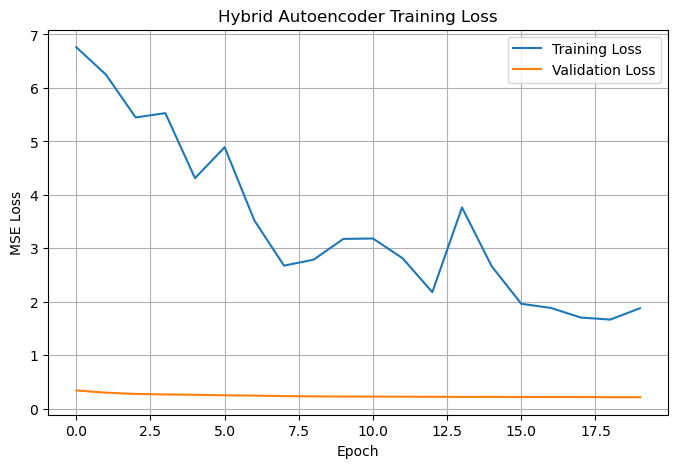

In [9]:

# --- Plot Loss ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

32994/32994 [==============================] - 178s 5ms/step


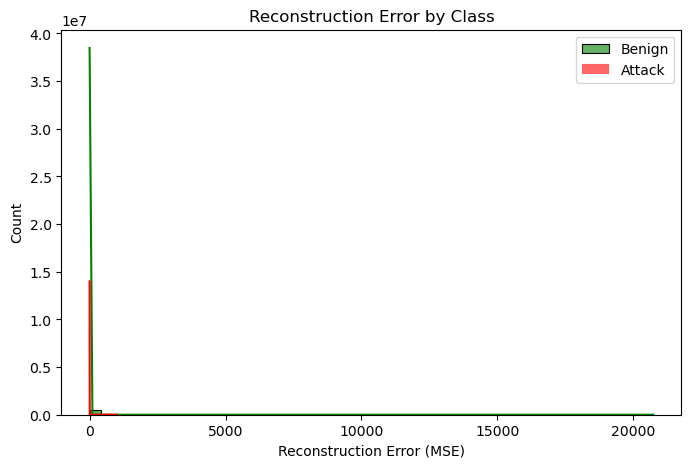

In [10]:
# --- Calculate Reconstruction Errors on Supervised Data ---
X_supervised_reconstructed = autoencoder.predict(X_supervised_lstm)
supervised_errors = np.mean(np.square(X_supervised_lstm - X_supervised_reconstructed), axis=(1,2))

# --- Plot Reconstruction Error Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(supervised_errors[y_supervised == 0], color='green', bins=50, alpha=0.6, label='Benign', kde=True)
sns.histplot(supervised_errors[y_supervised == 1], color='red', bins=50, alpha=0.6, label='Attack', kde=True)
plt.title('Reconstruction Error by Class')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.show()


In [11]:
# Remove NaNs from supervised_errors and corresponding labels
mask = ~np.isnan(supervised_errors)
cleaned_errors = supervised_errors[mask]
cleaned_labels = y_supervised[mask]

auc = roc_auc_score(cleaned_labels, cleaned_errors)
print(f"ROC-AUC Score based on reconstruction error: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(cleaned_labels, cleaned_errors)


ROC-AUC Score based on reconstruction error: 0.9033


In [12]:
print(np.isnan(X_supervised_scaled).sum())  # Should be 0
print(np.isnan(X_unsupervised_scaled).sum()) # Should be 0


0
0


ROC-AUC Score based on reconstruction error: 0.9033


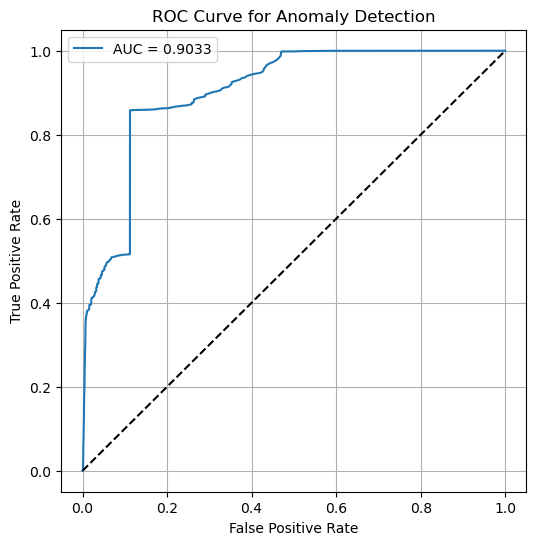

In [13]:
# --- ROC-AUC Evaluation ---
auc = roc_auc_score(y_supervised, supervised_errors)
print(f"ROC-AUC Score based on reconstruction error: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_supervised, supervised_errors)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid()
plt.show()

Optimal Threshold for anomaly detection: 0.068397


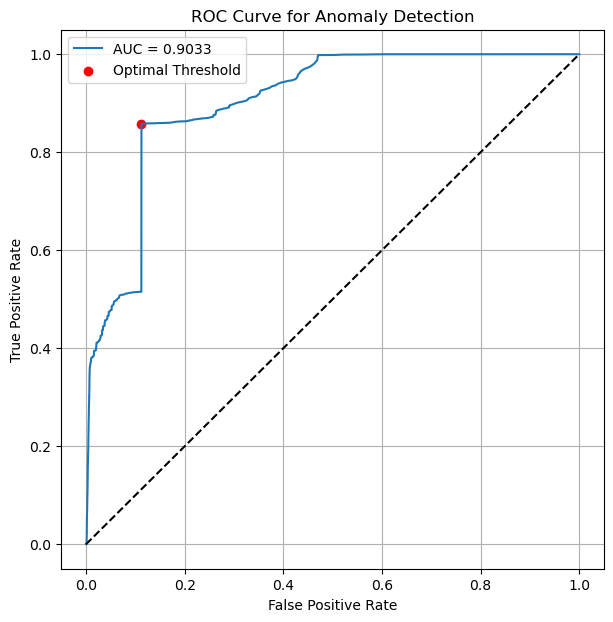

Average Precision Score: 0.8908


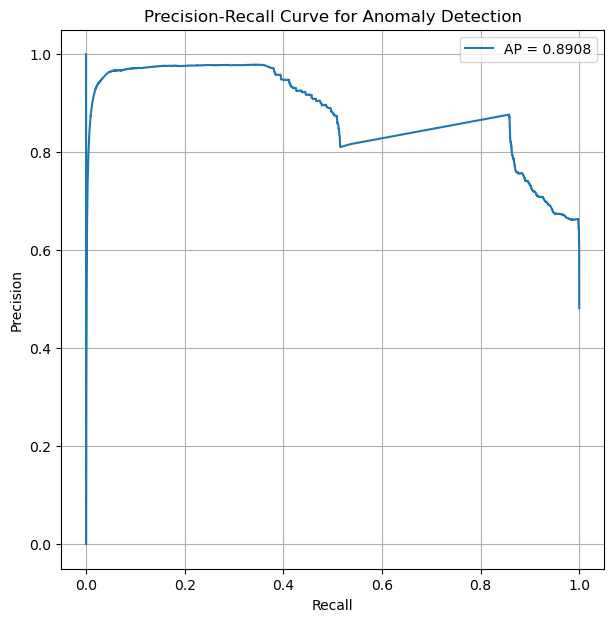

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Using existing fpr, tpr, thresholds from ROC curve
# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold for anomaly detection: {optimal_threshold:.6f}")

# Plot ROC curve with threshold
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='Optimal Threshold')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.grid(True)
plt.legend()
plt.show()

# Calculate Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(cleaned_labels, cleaned_errors)
ap_score = average_precision_score(cleaned_labels, cleaned_errors)
print(f'Average Precision Score: {ap_score:.4f}')

# Plot Precision-Recall Curve
plt.figure(figsize=(7,7))
plt.plot(recall, precision, label=f'AP = {ap_score:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from cvss import CVSS3
from decimal import Decimal

manual_reference = {
    "DDOS": 9.8,
    "PORTSCAN": 3.2,
    "BOT": 9.9,
    "HEARTBLEED": 7.5,
    "BENIGN": 0.0,
    "UNKNOWN": 5.0
}

vector_reference = {
    "DDOS": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H",
    "PORTSCAN": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:L/I:N/A:N",
    "BOT": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:H/I:H/A:H",
    "HEARTBLEED": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N",
    "BENIGN": "CVSS:3.1/AV:L/AC:H/PR:H/UI:R/S:U/C:N/I:N/A:N",
    "UNKNOWN": "CVSS:3.1/AV:N/AC:H/PR:H/UI:R/S:C/C:L/I:L/A:L"
}

def compute_cvss_score(attack):
    manual = manual_reference.get(attack.upper(), 0.0)
    vector_str = vector_reference.get(attack.upper(), "")

    try:
        cvss = CVSS3(vector_str)
        vector = float(cvss.scores()[0])  # convert Decimal → float
        severity = cvss.severities()[0]
    except Exception as e:
        print(f"Error for {attack}: {e}")
        vector = 0.0
        severity = "ERROR"

    hybrid = round((manual + vector) / 2, 2)
    return {"Manual": manual, "Vector": vector, "Hybrid": hybrid, "Severity": severity}


In [16]:
attacks = ["DDOS", "PORTSCAN", "BOT", "HEARTBLEED", "BENIGN", "UNKNOWN"]

for attack in attacks:
    result = compute_cvss_score(attack)
    print(f"{attack} → {result}")


DDOS → {'Manual': 9.8, 'Vector': 9.8, 'Hybrid': 9.8, 'Severity': 'Critical'}
PORTSCAN → {'Manual': 3.2, 'Vector': 5.3, 'Hybrid': 4.25, 'Severity': 'Medium'}
BOT → {'Manual': 9.9, 'Vector': 10.0, 'Hybrid': 9.95, 'Severity': 'Critical'}
HEARTBLEED → {'Manual': 7.5, 'Vector': 7.5, 'Hybrid': 7.5, 'Severity': 'High'}
BENIGN → {'Manual': 0.0, 'Vector': 0.0, 'Hybrid': 0.0, 'Severity': 'None'}
UNKNOWN → {'Manual': 5.0, 'Vector': 5.1, 'Hybrid': 5.05, 'Severity': 'Medium'}


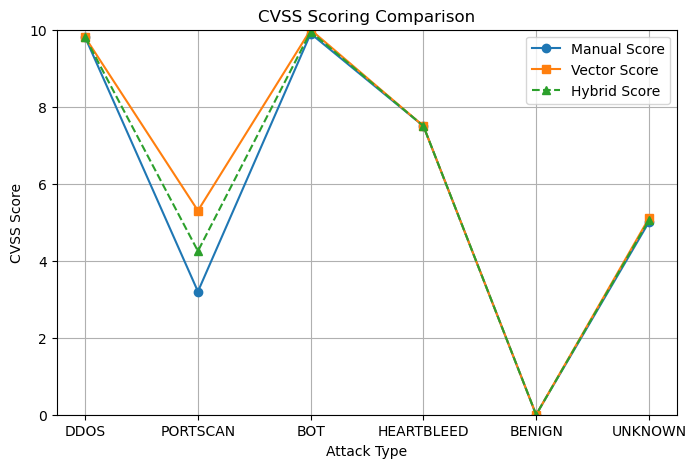

In [17]:
import matplotlib.pyplot as plt

attacks = ["DDOS", "PORTSCAN", "BOT", "HEARTBLEED", "BENIGN", "UNKNOWN"]
manual = [9.8, 3.2, 9.9, 7.5, 0.0, 5.0]
vector = [9.8, 5.3, 10.0, 7.5, 0.0, 5.1]
hybrid = [9.8, 4.25, 9.95, 7.5, 0.0, 5.05]

plt.figure(figsize=(8,5))
plt.plot(attacks, manual, marker='o', label='Manual Score')
plt.plot(attacks, vector, marker='s', label='Vector Score')
plt.plot(attacks, hybrid, marker='^', label='Hybrid Score', linestyle='--')
plt.title("CVSS Scoring Comparison")
plt.xlabel("Attack Type")
plt.ylabel("CVSS Score")
plt.ylim(0, 10)
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import paho.mqtt
print(paho.mqtt.__version__)

2.1.0


In [19]:
!pip install streamlit



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
!pip install flask


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Imports and logging
import json
import time
import logging
import random
import threading
import requests
import paho.mqtt.client as mqtt
from flask import Flask, jsonify
import streamlit as st
from collections import deque

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

###############################################
# Mock Nuclear Plant API Server (Flask)
###############################################

app = Flask(__name__)
network_segments_isolated = set()
systems_shutdown = set()

def simulate_delay(min_sec=0.5, max_sec=2):
    delay = random.uniform(min_sec, max_sec)
    logging.info(f"Simulating delay: {delay:.2f} seconds")
    time.sleep(delay)

@app.route('/isolate/<segment_id>', methods=['POST'])
def isolate_segment(segment_id):
    simulate_delay()
    if segment_id in network_segments_isolated:
        msg = f"Segment {segment_id} already isolated."
        logging.warning(msg)
        return jsonify({"status": "failure", "msg": msg}), 400
    network_segments_isolated.add(segment_id)
    msg = f"Segment {segment_id} isolated successfully."
    logging.info(msg)
    return jsonify({"status": "success", "msg": msg}), 200

@app.route('/shutdown/<system_id>', methods=['POST'])
def emergency_shutdown(system_id):
    simulate_delay()
    if system_id in systems_shutdown:
        msg = f"System {system_id} already shut down."
        logging.warning(msg)
        return jsonify({"status": "failure", "msg": msg}), 400
    systems_shutdown.add(system_id)
    msg = f"Emergency shutdown of system {system_id} initiated."
    logging.info(msg)
    return jsonify({"status": "success", "msg": msg}), 200

# Run API in background thread
def run_api():
    app.run(host='0.0.0.0', port=5000)

threading.Thread(target=run_api, daemon=True).start()
logging.info("Mock Nuclear Plant API started.")

###############################################
# API Helper Functions
###############################################

ISOLATION_API_BASE_URL = "http://localhost:5000"

def isolate_segment_api(segment_id):
    try:
        response = requests.post(f"{ISOLATION_API_BASE_URL}/isolate/{segment_id}", timeout=5)
        return response.status_code, response.json().get("msg", "")
    except Exception as e:
        logging.error(f"Isolation API error: {e}")
        return None, str(e)

def emergency_shutdown_api(system_id):
    try:
        response = requests.post(f"{ISOLATION_API_BASE_URL}/shutdown/{system_id}", timeout=5)
        return response.status_code, response.json().get("msg", "")
    except Exception as e:
        logging.error(f"Shutdown API error: {e}")
        return None, str(e)

###############################################
# Agentic AI - Simple Rule-Based Decision Simulation
###############################################

def agentic_ai_refined_decision(cvss_base_score, sensor_data):
    """
    Simple rule to refine severity decision based on CVSS base score and sensor values.
    Returns severity and reason.
    """
    # Rules for demo purposes:
    if cvss_base_score >= 9.0 or sensor_data.get("radiation_level", 0) > 4.0:
        return "Critical", "High CVSS or dangerous radiation detected"
    elif cvss_base_score >= 7.0 or sensor_data.get("temperature_c", 0) > 80:
        return "High", "Elevated CVSS or temperature"
    elif cvss_base_score >= 4.0:
        return "Medium", "Moderate CVSS score"
    else:
        return "Low", "Low CVSS and normal sensor readings"

###############################################
# Remedial Actions for Self-Healing
###############################################

def trigger_action(severity, reason):
    action = "No action taken."

    if severity == "Low":
        action = "Monitoring only."
    elif severity == "Medium":
        status, msg = isolate_segment_api("segment-001")
        action = f"Isolation attempt. Status: {status}, Message: {msg}"
    elif severity == "High":
        status, msg = emergency_shutdown_api("reactor-1")
        action = f"Shutdown attempt. Status: {status}, Message: {msg}"
    elif severity == "Critical":
        status, msg = emergency_shutdown_api("reactor-1")
        action = f"CRITICAL shutdown attempt. Status: {status}, Message: {msg}"

    logging.info(action)
    return action

###############################################
# MQTT Publisher - Telemetry & Refined Decision
###############################################

mqtt_client = mqtt.Client(client_id="Publisher")
mqtt_client.connect("localhost", 1883)

def generate_telemetry():
    return {
        "radiation_level": round(random.uniform(0, 5), 2),
        "temperature_c": round(random.uniform(20, 100), 1),
        "valve_status": random.choice(["open", "closed"]),
        "sensor_fault": random.choice([True, False])
    }

def publish_loop():
    while True:
        telemetry = generate_telemetry()
        # Use a dummy CVSS base score for demo, random in realistic range
        cvss_base_score = round(random.uniform(0, 10), 1)
        severity, reason = agentic_ai_refined_decision(cvss_base_score, telemetry)

        mqtt_client.publish("plant/telemetry", json.dumps(telemetry))
        mqtt_client.publish("refined/decision", json.dumps({
            "cvss_base_score": cvss_base_score,
            "refined_severity": severity,
            "reason": reason
        }))
        logging.info(f"Published telemetry and refined decision: Severity={severity}, Reason={reason}")
        time.sleep(5)

threading.Thread(target=publish_loop, daemon=True).start()



2025-11-24 01:45:58,024 - INFO - Mock Nuclear Plant API started.


 * Serving Flask app '__main__'
 * Debug mode: off


2025-11-24 01:45:58,075 - INFO - Published telemetry and refined decision: Severity=Critical, Reason=High CVSS or dangerous radiation detected
2025-11-24 01:45:58,099 - INFO - WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.107:5000
2025-11-24 01:45:58,102 - INFO - Press CTRL+C to quit
2025-11-24 01:46:03,104 - INFO - Published telemetry and refined decision: Severity=Critical, Reason=High CVSS or dangerous radiation detected
2025-11-24 01:46:05,165 - INFO - Simulating delay: 1.81 seconds
2025-11-24 01:46:06,990 - INFO - Emergency shutdown of system reactor-1 initiated.
2025-11-24 01:46:06,999 - INFO - 127.0.0.1 - - [24/Nov/2025 01:46:06] "POST /shutdown/reactor-1 HTTP/1.1" 200 -
2025-11-24 01:46:08,121 - INFO - Published telemetry and refined decision: Severity=High, Reason=Elevated CVSS or temperature
2025-11-2

In [ ]:
import json
import logging
import threading
import time
import csv
from collections import deque
import paho.mqtt.client as mqtt

# Filename to store logs persistently
LOG_FILE = "selfhealing_feedback_log.csv"

# In-memory recent logs buffer (optional, for quick access)
recent_logs = deque(maxlen=1000)

# Initialize CSV file with headers if it does not exist
try:
    with open(LOG_FILE, "x", newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp", "severity", "reason", "action"])
except FileExistsError:
    # File already exists, no action needed
    pass

def log_feedback(timestamp, severity, reason, action):
    # Append to CSV file
    with open(LOG_FILE, "a", newline='') as f:
        writer = csv.writer(f)
        writer.writerow([timestamp, severity, reason, action])

    # Append to in-memory buffer
    recent_logs.append({
        "timestamp": timestamp,
        "severity": severity,
        "reason": reason,
        "action": action
    })

def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())
        severity = data.get("refined_severity", "Low")
        reason = data.get("reason", "")
        action_taken = trigger_action(severity, reason)

        timestamp = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
        log_feedback(timestamp, severity, reason, action_taken)

        # Publish the status
        status_msg = json.dumps({
            "timestamp": timestamp,
            "severity": severity,
            "action": action_taken,
            "reason": reason
        })
        client.publish("selfhealing/status", status_msg)

        logging.info(f"Logged and published action: {status_msg}")

    except Exception as e:
        logging.error(f"Error handling decision message: {e}")

# Setup subscriber client
subscriber_client = mqtt.Client(client_id="SelfHealingAgent")
subscriber_client.connect("localhost", 1883)
subscriber_client.subscribe("refined/decision")
subscriber_client.on_message = on_message
subscriber_client.loop_start()


<MQTTErrorCode.MQTT_ERR_SUCCESS: 0>

2025-11-24 01:46:07,012 - INFO - CRITICAL shutdown attempt. Status: 200, Message: Emergency shutdown of system reactor-1 initiated.
2025-11-24 01:46:07,031 - INFO - Logged and published action: {"timestamp": "2025-11-24 01:46:07", "severity": "Critical", "action": "CRITICAL shutdown attempt. Status: 200, Message: Emergency shutdown of system reactor-1 initiated.", "reason": "High CVSS or dangerous radiation detected"}
2025-11-24 01:46:12,159 - INFO - Shutdown attempt. Status: 400, Message: System reactor-1 already shut down.
2025-11-24 01:46:12,168 - INFO - Logged and published action: {"timestamp": "2025-11-24 01:46:12", "severity": "High", "action": "Shutdown attempt. Status: 400, Message: System reactor-1 already shut down.", "reason": "Elevated CVSS or temperature"}
2025-11-24 01:46:15,923 - INFO - Shutdown attempt. Status: 400, Message: System reactor-1 already shut down.
2025-11-24 01:46:15,929 - INFO - Logged and published action: {"timestamp": "2025-11-24 01:46:15", "severity":

In [1]:
import psutil, os
print(f"Memory usage (MB):", psutil.Process(os.getpid()).memory_info().rss / 1024 ** 2)


Memory usage (MB): 63.34375


In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv('selfhealing_feedback_log.csv')
print(df.columns)

# One-hot encode reason and action for ML features
X = pd.get_dummies(df[['reason', 'action']]).values   # <-- as numpy array!
y = df['severity'].values

# Reshape for LSTM (samples, 1, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Split data into 3 chunks for client simulation
X_splits = np.array_split(X, 3)
y_splits = np.array_split(y, 3)


Index(['timestamp', 'severity', 'reason', 'action'], dtype='object')


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

def make_model(input_shape, num_classes=4):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.LSTM(32, return_sequences=True)(inputs)
    x = layers.LSTM(16)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('selfhealing_feedback_log.csv')
X = pd.get_dummies(df[['reason', 'action']]).values
y, severity_categories = pd.factorize(df['severity'])

# Only for LSTM models:
X = X.reshape((X.shape[0], 1, X.shape[1]))  # COMMENT THIS if using Dense only

n_clients = 3
X_splits = np.array_split(X, n_clients)
y_splits = np.array_split(y, n_clients)
input_shape = X_splits[0].shape[1:]

# Define your model here
from tensorflow.keras import layers, models
def make_model(input_shape, num_classes=4):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(16)(inputs)  # or use Dense if not sequential
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

global_model = make_model(input_shape, num_classes=len(severity_categories))

n_rounds = 10
for rnd in range(n_rounds):
    weights = []
    for i in range(n_clients):
        client_model = make_model(input_shape, num_classes=len(severity_categories))
        client_model.set_weights(global_model.get_weights())
        client_model.fit(X_splits[i], y_splits[i], batch_size=16, epochs=1, verbose=0)
        weights.append(client_model.get_weights())
    new_weights = [np.mean([w[i] for w in weights], axis=0) for i in range(len(weights[0]))]
    global_model.set_weights(new_weights)
    print(f"Completed federated round {rnd+1}")


In [ ]:
new_weights = [np.mean([w[i] for w in weights], axis=0) for i in range(len(weights[0]))]


In [ ]:
!streamlit run dashbord.py